# Physics-Informed Optical AI Receiver

A computational optical receiver that reconstructs optical phase from **intensity-only**
measurements and verifies the reconstruction using physics consistency checks plus a small
physics-informed AI confidence estimator.

**Dataset:** Dryad DOI [10.5061/dryad.2h7d2](https://doi.org/10.5061/dryad.2h7d2) — fiber-Bragg-grating
group-delay / dispersion intensity traces. A local extract already lives in `data/raw/`
(`pipeline_input.npz`, `pipeline_input.mat`, `raw_traces.npz`, `fbg_group_delay.npy`,
`measurement_metadata.json`). The loader below is generic: point it at any directory and it
will recursively discover and load every supported file it can.

```text
Dataset
   |
Loader
   |
Preprocessing
   |
Intensity traces
   |
TDGSA
   |
Recovered complex field
   |
Physics verification
   |
AI confidence estimator
   |
PASS / CHECK / FAIL
```

**Design principle.** We never compare the recovered phase to a hidden "true phase" for the
experimental dataset — there isn't one. Success is judged by physical self-consistency: does
the recovered field reproduce the measured intensity, conserve energy, stay smooth, and remain
stable across independent random restarts? A synthetic dataset (Part 2) is the *only* place a
ground-truth phase is used, purely as a sanity check on the algorithm itself.


In [1]:
# ---------------------------------------------------------------------------
# Environment / reproducibility
# ---------------------------------------------------------------------------
import math, os, time, json, glob, warnings
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

import torch
import torch.nn as nn

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATASET_DIR = Path("../data/raw")   # local Dryad 10.5061/dryad.2h7d2 extract
DATASET_DOI = "10.5061/dryad.2h7d2"

NOTEBOOK_T0 = time.time()

print(f"seed={SEED}  device={DEVICE}  dataset_dir={DATASET_DIR.resolve()}")
print(f"numpy {np.__version__} | pandas {pd.__version__} | torch {torch.__version__} | sympy {sp.__version__}")


seed=7  device=cuda  dataset_dir=D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\data\raw
numpy 2.4.4 | pandas 2.3.3 | torch 2.11.0+cu128 | sympy 1.14.0


## Loader — recursive multi-format dataset discovery

Walks a directory tree and tries to load every file whose extension is one of
`.mat`, `.npz`, `.npy`, `.csv`, `.dat`, `.txt`. Unsupported or unreadable files are skipped
with a logged reason rather than raising. Every successfully loaded array (or array-valued
field inside a container format) becomes one row of a summary table.


In [2]:
# ---------------------------------------------------------------------------
# Generic recursive multi-format loader
# ---------------------------------------------------------------------------
import scipy.io as spio

SUPPORTED_EXTS = {".mat", ".npz", ".npy", ".csv", ".dat", ".txt"}

@dataclass
class LoadedArray:
    source_file: str
    field_name: str
    array: np.ndarray
    n_samples: int
    dtype: str
    file_kind: str

def _is_plottable_1d(a: np.ndarray) -> bool:
    if a is None or not isinstance(a, np.ndarray):
        return False
    if a.dtype.kind not in "fiu":
        return False
    return a.ndim == 1 and a.size >= 8

def _load_mat(path: Path):
    out = []
    try:
        m = spio.loadmat(str(path))
    except Exception as e:
        return [], f"mat read failed: {e}"
    for k, v in m.items():
        if k.startswith("__"):
            continue
        v = np.asarray(v).squeeze()
        if _is_plottable_1d(v):
            out.append(LoadedArray(path.name, k, v.astype(np.float64), v.size, str(v.dtype), "mat"))
    return out, None

def _load_npz(path: Path):
    out = []
    try:
        d = np.load(str(path), allow_pickle=True)
    except Exception as e:
        return [], f"npz read failed: {e}"
    for k in d.files:
        v = np.asarray(d[k]).squeeze()
        if _is_plottable_1d(v):
            out.append(LoadedArray(path.name, k, v.astype(np.float64), v.size, str(v.dtype), "npz"))
    return out, None

def _load_npy(path: Path):
    try:
        v = np.asarray(np.load(str(path), allow_pickle=True)).squeeze()
    except Exception as e:
        return [], f"npy read failed: {e}"
    if _is_plottable_1d(v):
        return [LoadedArray(path.name, path.stem, v.astype(np.float64), v.size, str(v.dtype), "npy")], None
    return [], "npy: not a plottable 1D numeric array"

def _load_delimited(path: Path, sep=None):
    try:
        df = pd.read_csv(path, sep=sep, engine="python", comment="#", header=None)
    except Exception as e:
        return [], f"delimited read failed: {e}"
    out = []
    numeric_df = df.apply(pd.to_numeric, errors="coerce")
    for col in numeric_df.columns:
        v = numeric_df[col].dropna().to_numpy(dtype=np.float64)
        if _is_plottable_1d(v):
            out.append(LoadedArray(path.name, f"col{col}", v, v.size, "float64", path.suffix.lstrip(".")))
    return out, (None if out else "no numeric columns found")

def discover_dataset(root: Path):
    # Recursively scan `root`, load every supported file, return (records, skipped).
    records, skipped = [], []
    if not root.exists():
        return records, [{"file": str(root), "reason": "dataset directory not found"}]
    for path in sorted(root.rglob("*")):
        if not path.is_file():
            continue
        ext = path.suffix.lower()
        if ext not in SUPPORTED_EXTS:
            skipped.append({"file": str(path), "reason": f"unsupported extension '{ext}'"})
            continue
        if ext == ".mat":
            loaded, err = _load_mat(path)
        elif ext == ".npz":
            loaded, err = _load_npz(path)
        elif ext == ".npy":
            loaded, err = _load_npy(path)
        elif ext in (".csv",):
            loaded, err = _load_delimited(path, sep=",")
        else:  # .dat, .txt
            loaded, err = _load_delimited(path, sep=None)
        if loaded:
            records.extend(loaded)
        if err:
            skipped.append({"file": str(path), "reason": err})
    return records, skipped

records, skipped = discover_dataset(DATASET_DIR)
print(f"Loaded {len(records)} numeric traces from {DATASET_DIR}")
print(f"Skipped {len(skipped)} files/fields:")
for s in skipped[:10]:
    print("  -", s["file"], "->", s["reason"])


Loaded 11 numeric traces from ..\data\raw
Skipped 1 files/fields:
  - ..\data\raw\measurement_metadata.json -> unsupported extension '.json'


In [3]:
# ---------------------------------------------------------------------------
# Dataset summary DataFrame
# ---------------------------------------------------------------------------
def summarize(records):
    rows = []
    for r in records:
        a = r.array
        rows.append({
            "source_file": r.source_file,
            "field": r.field_name,
            "kind": r.file_kind,
            "n_samples": r.n_samples,
            "dtype": r.dtype,
            "min": float(np.min(a)),
            "max": float(np.max(a)),
            "mean": float(np.mean(a)),
            "std": float(np.std(a)),
        })
    return pd.DataFrame(rows)

summary_df = summarize(records)
summary_df


,source_file,field,kind,n_samples,dtype,min,max,mean,std
0,fbg_group_delay.npy,fbg_group_delay,npy,40000,float64,-5.534345e-09,5.419631e-09,-4.932321e-10,4.488247e-09
1,pipeline_input.mat,i1,mat,40000,float32,0.000000e+00,1.000000e+00,5.000000e-01,2.886823e-01
2,pipeline_input.mat,i2,mat,40000,float32,0.000000e+00,1.000000e+00,5.055194e-01,1.991359e-01
3,pipeline_input.mat,time,mat,40000,int64,0.000000e+00,3.999900e+04,1.999950e+04,1.154701e+04
4,pipeline_input.mat,group_delay,mat,40000,float64,-5.534345e-09,5.419631e-09,-4.932321e-10,4.488247e-09
5,pipeline_input.npz,i1,npz,40000,float32,0.000000e+00,1.000000e+00,5.000000e-01,2.886823e-01
6,pipeline_input.npz,i2,npz,40000,float32,0.000000e+00,1.000000e+00,5.055194e-01,1.991359e-01
7,pipeline_input.npz,time,npz,40000,int64,0.000000e+00,3.999900e+04,1.999950e+04,1.154701e+04
8,pipeline_input.npz,group_delay,npz,40000,float64,-5.534345e-09,5.419631e-09,-4.932321e-10,4.488247e-09
9,raw_traces.npz,i1,npz,40000,float32,0.000000e+00,1.000000e+00,5.000000e-01,2.886823e-01


## Part 1 — Data Exploration

Normalize every trace to `[0, 1]` (min-max), then look at it from several angles: raw traces,
a heatmap stacking all traces together, FFT magnitude (frequency content), and a histogram of
sample values.


In [4]:
# ---------------------------------------------------------------------------
# Consistent normalization
# ---------------------------------------------------------------------------
def normalize_trace(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=np.float64)
    lo, hi = np.min(a), np.max(a)
    if hi - lo < 1e-15:
        return np.zeros_like(a)
    return (a - lo) / (hi - lo)

normalized = [normalize_trace(r.array) for r in records]
labels = [f"{r.source_file}:{r.field_name}" for r in records]
print(f"Normalized {len(normalized)} traces (min-max -> [0,1])")


Normalized 11 traces (min-max -> [0,1])


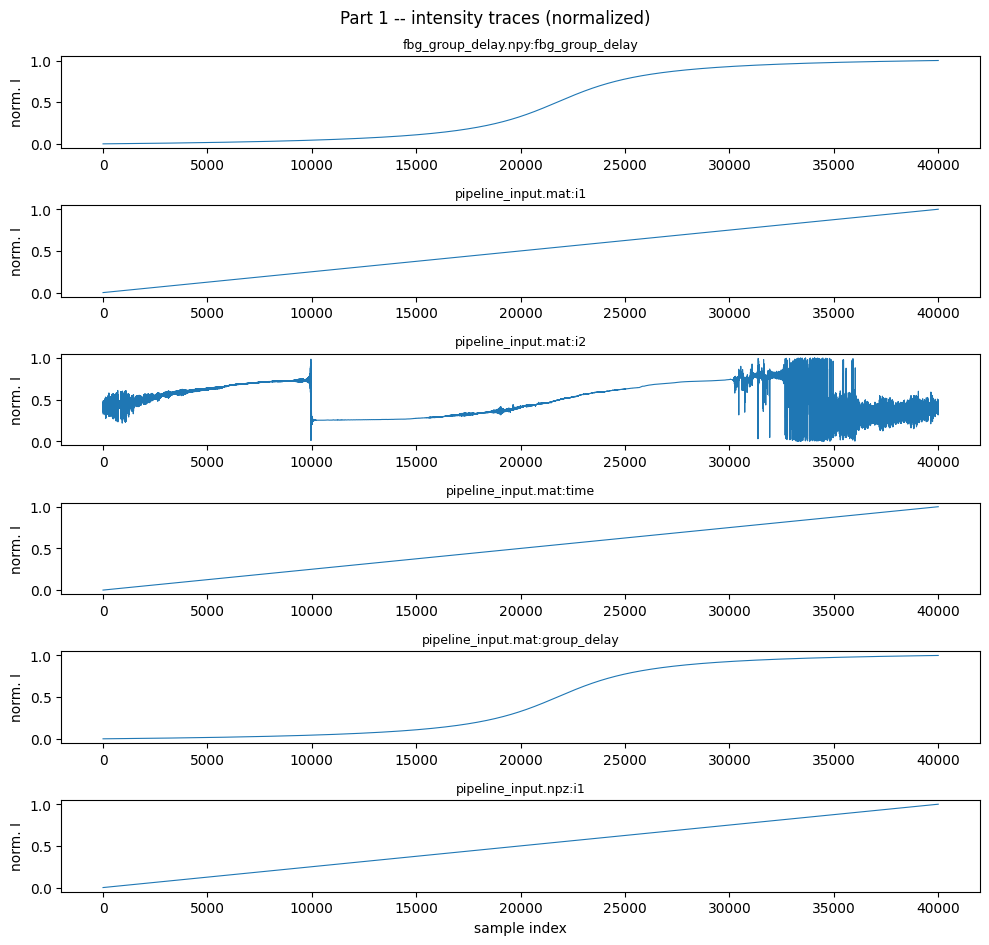

In [5]:
# ---------------------------------------------------------------------------
# Trace plots
# ---------------------------------------------------------------------------
n_show = min(6, len(normalized))
fig, axes = plt.subplots(n_show, 1, figsize=(10, 1.6 * n_show), sharex=False)
if n_show == 1:
    axes = [axes]
for ax, x, lab in zip(axes, normalized[:n_show], labels[:n_show]):
    ax.plot(x, lw=0.8)
    ax.set_title(lab, fontsize=9)
    ax.set_ylabel("norm. I")
axes[-1].set_xlabel("sample index")
fig.suptitle("Part 1 -- intensity traces (normalized)")
fig.tight_layout()
plt.show()


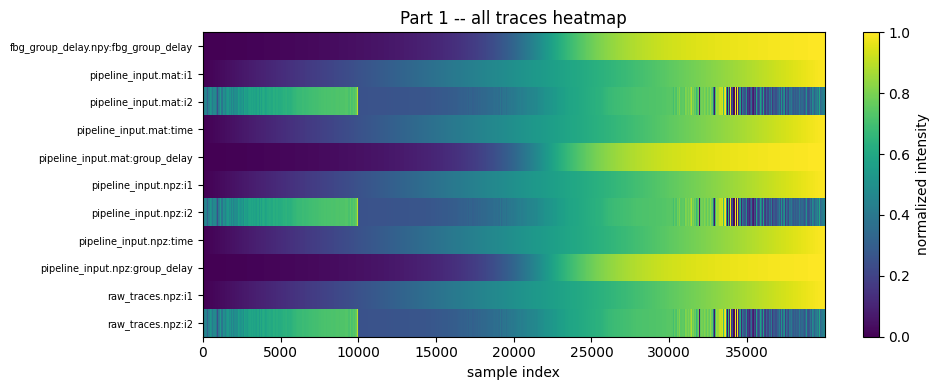

In [6]:
# ---------------------------------------------------------------------------
# Heatmap of all traces (resampled to common length for stacking)
# ---------------------------------------------------------------------------
if normalized:
    common_len = min(len(x) for x in normalized)
    stack = np.stack([x[:common_len] for x in normalized])
    plt.figure(figsize=(10, 4))
    plt.imshow(stack, aspect="auto", cmap="viridis", interpolation="nearest")
    plt.colorbar(label="normalized intensity")
    plt.yticks(range(len(labels)), labels, fontsize=7)
    plt.xlabel("sample index")
    plt.title("Part 1 -- all traces heatmap")
    plt.tight_layout()
    plt.show()


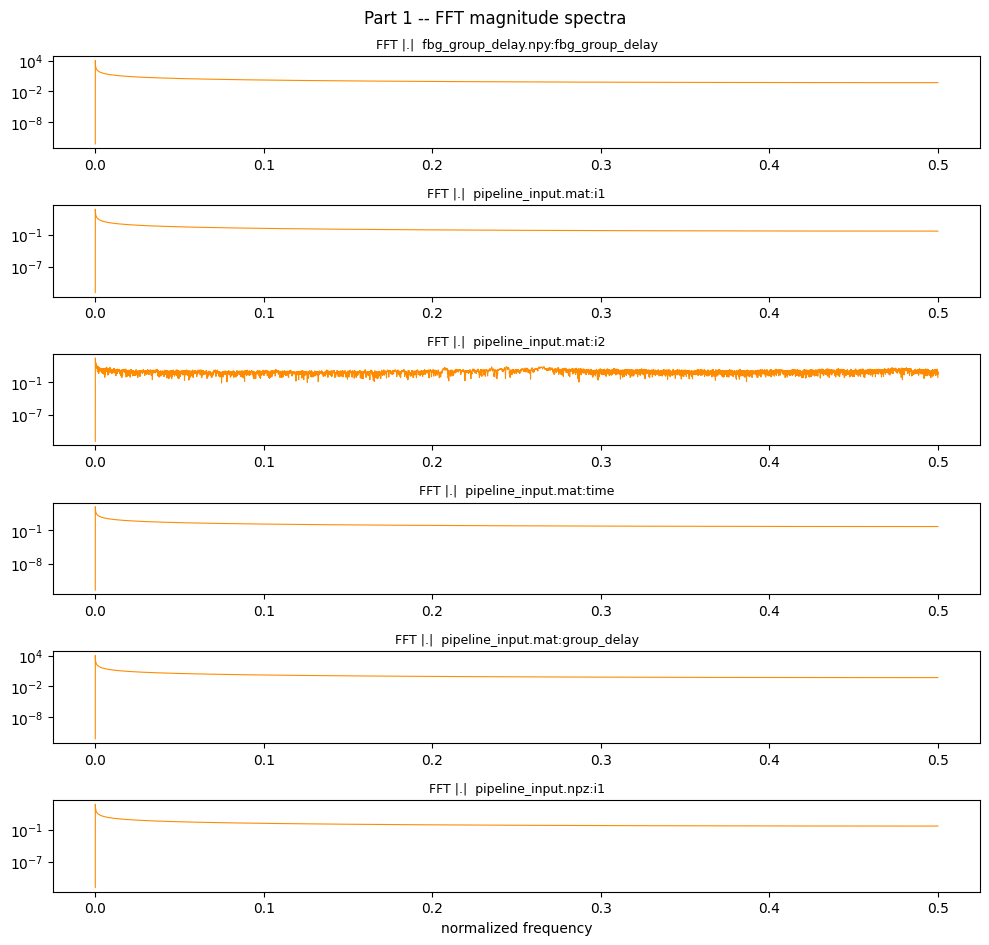

In [7]:
# ---------------------------------------------------------------------------
# FFT magnitude plots
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(n_show, 1, figsize=(10, 1.6 * n_show))
if n_show == 1:
    axes = [axes]
for ax, x, lab in zip(axes, normalized[:n_show], labels[:n_show]):
    spec = np.abs(np.fft.rfft(x - x.mean()))
    freqs = np.fft.rfftfreq(len(x))
    ax.plot(freqs, spec, lw=0.8, color="darkorange")
    ax.set_yscale("log")
    ax.set_title(f"FFT |.|  {lab}", fontsize=9)
axes[-1].set_xlabel("normalized frequency")
fig.suptitle("Part 1 -- FFT magnitude spectra")
fig.tight_layout()
plt.show()


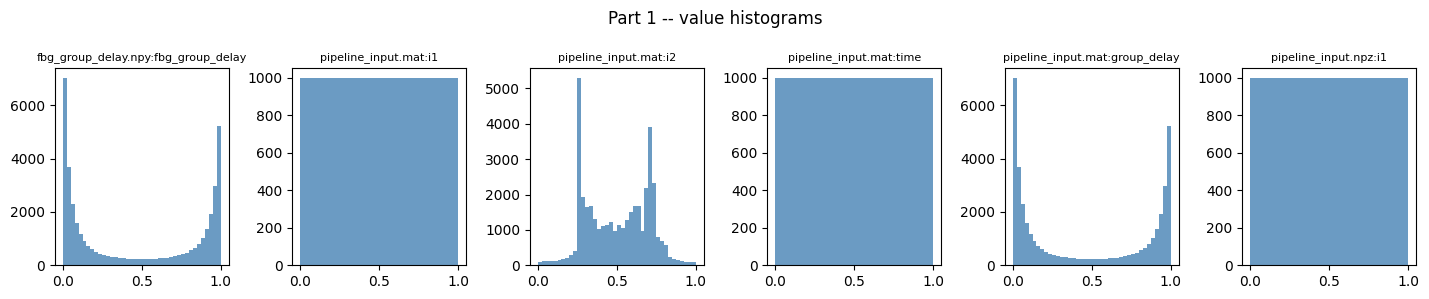

,source_file,field,kind,n_samples,dtype,min,max,mean,std
count,11,11,11,11.0,11,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01
unique,4,5,3,NaN,3,NaN,NaN,NaN,NaN
top,pipeline_input.mat,i1,npz,NaN,float32,NaN,NaN,NaN,NaN
freq,4,3,6,NaN,6,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,40000.0,NaN,-1.509367e-09,7.273091e+03,3.636547e+03,2.099589e+03
std,NaN,NaN,NaN,0.0,NaN,2.585089e-09,1.618012e+04,8.090061e+03,4.670928e+03
min,NaN,NaN,NaN,40000.0,NaN,-5.534345e-09,5.419631e-09,-4.932321e-10,4.488247e-09
25%,NaN,NaN,NaN,40000.0,NaN,-2.767173e-09,5.000000e-01,2.500000e-01,9.956797e-02
50%,NaN,NaN,NaN,40000.0,NaN,0.000000e+00,1.000000e+00,5.000000e-01,1.991359e-01
75%,NaN,NaN,NaN,40000.0,NaN,0.000000e+00,1.000000e+00,5.055194e-01,2.886823e-01


In [8]:
# ---------------------------------------------------------------------------
# Histograms
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, n_show, figsize=(2.4 * n_show, 3))
if n_show == 1:
    axes = [axes]
for ax, x, lab in zip(axes, normalized[:n_show], labels[:n_show]):
    ax.hist(x, bins=40, color="steelblue", alpha=0.8)
    ax.set_title(lab, fontsize=8)
fig.suptitle("Part 1 -- value histograms")
fig.tight_layout()
plt.show()

summary_df.describe(include="all")


## Part 2 — TDGSA: Time-Domain Gerchberg–Saxton Algorithm

The detector only measures intensity $I(t) = |E(t)|^2$; the phase is discarded. TDGSA recovers
a self-consistent complex field $E(t) = A(t)e^{i\phi(t)}$ by alternately enforcing the measured
*time-domain* magnitude and the propagation model's *spectral* magnitude, exactly as the
classical Gerchberg–Saxton algorithm alternates between two domains' magnitude constraints.

We treat `i1` as the primary measured intensity trace. A second trace `i2` (if present) acts as
an independent magnitude constraint after a known dispersive transfer function $H(\nu)$,
analogous to a chirped-pulse-retrieval setup.


In [9]:
# ---------------------------------------------------------------------------
# Modular TDGSA implementation
# ---------------------------------------------------------------------------
def tdgsa(mag1: np.ndarray, n_iter: int = 200, mag2: np.ndarray = None,
          H: np.ndarray = None, seed: int = 0):
    # Enforces measured magnitude `mag1` every iteration. If `mag2` and a transfer
    # function `H` (frequency-domain, same length as mag1) are given, also enforces
    # `mag2` on H-filtered field, coupling two intensity constraints (dual-domain GS).
    # Returns the recovered complex field and the per-iteration magnitude-MSE history.
    rng = np.random.default_rng(seed)
    mag1 = np.asarray(mag1, dtype=np.float64)
    N = mag1.size
    phase = rng.uniform(-np.pi, np.pi, size=N)
    E = mag1 * np.exp(1j * phase)
    errors = []
    for _ in range(int(n_iter)):
        if mag2 is not None and H is not None:
            E2 = np.fft.ifft(np.fft.fft(E) * H)
            E2 = mag2 * np.exp(1j * np.angle(E2))
            E = np.fft.ifft(np.fft.fft(E2) / H)
        E = mag1 * np.exp(1j * np.angle(E))
        err = float(np.mean((np.abs(E) - mag1) ** 2))
        errors.append(err)
    return E, np.array(errors)

def recovered_intensity(E: np.ndarray) -> np.ndarray:
    return np.abs(E) ** 2

# pick the primary trace: prefer the field literally named "i1", else first record
def find_field(name):
    for r in records:
        if r.field_name.lower() == name:
            return r
    return None

rec_i1 = find_field("i1") or (records[0] if records else None)
rec_i2 = find_field("i2")

if rec_i1 is None:
    raise RuntimeError("No usable intensity trace found in dataset -- check DATASET_DIR")

i1_raw = rec_i1.array
mag1 = np.sqrt(np.clip(normalize_trace(i1_raw), 0, None))

mag2, H = None, None
if rec_i2 is not None and rec_i2.array.size == i1_raw.size:
    i2_raw = rec_i2.array
    mag2 = np.sqrt(np.clip(normalize_trace(i2_raw), 0, None))
    N = mag1.size
    freq = np.fft.fftfreq(N)
    beta2_proxy = 0.6  # dimensionless dispersion proxy; dataset is FBG group-delay data
    H = np.exp(-1j * np.pi * beta2_proxy * (2 * np.pi * freq) ** 2)
    print(f"Using dual-domain TDGSA with i1 + i2 (N={N})")
else:
    print(f"Using single-domain TDGSA with i1 only (N={mag1.size})")

t_gs0 = time.time()
E_rec, gs_errors = tdgsa(mag1, n_iter=300, mag2=mag2, H=H, seed=SEED)
gs_runtime = time.time() - t_gs0
print(f"TDGSA finished in {gs_runtime:.3f}s, final magnitude-MSE = {gs_errors[-1]:.3e}")


Using dual-domain TDGSA with i1 + i2 (N=40000)


TDGSA finished in 1.267s, final magnitude-MSE = 4.094e-33


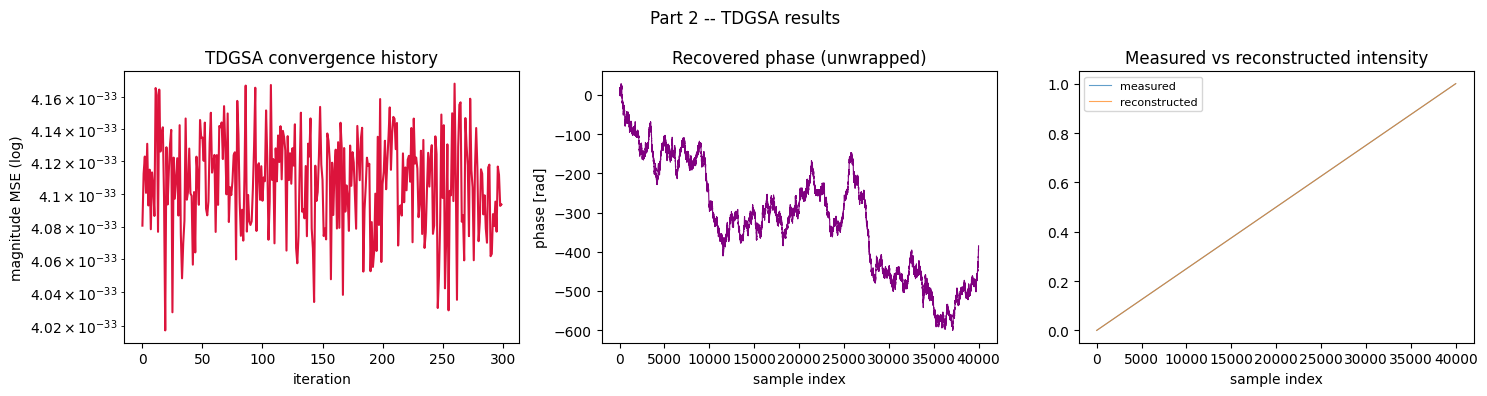

In [10]:
# ---------------------------------------------------------------------------
# Convergence history, recovered phase, reconstructed intensity
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(gs_errors, color="crimson")
axes[0].set_title("TDGSA convergence history")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("magnitude MSE (log)")

phase_rec = np.unwrap(np.angle(E_rec))
axes[1].plot(phase_rec, color="purple", lw=0.8)
axes[1].set_title("Recovered phase (unwrapped)")
axes[1].set_xlabel("sample index")
axes[1].set_ylabel("phase [rad]")

I_rec = recovered_intensity(E_rec)
I_meas = mag1 ** 2
axes[2].plot(I_meas, label="measured", lw=0.8, alpha=0.7)
axes[2].plot(I_rec, label="reconstructed", lw=0.8, alpha=0.7)
axes[2].set_title("Measured vs reconstructed intensity")
axes[2].legend(fontsize=8)
axes[2].set_xlabel("sample index")

fig.suptitle("Part 2 -- TDGSA results")
fig.tight_layout()
plt.show()


## Part 3 — Physics Verification

We never assume a hidden true phase exists. Instead we check that the recovered field is
*physically self-consistent*:

| Metric | What it checks |
|---|---|
| Intensity MSE / correlation | does $\lvert E_{rec}\rvert^2$ reproduce the measurement? |
| Energy conservation error | does total energy match within tolerance? |
| Phase smoothness | is $\phi(t)$ free of unphysical jitter? |
| Group-delay smoothness | is $\tau_g = -d\phi/d\omega$ smooth (no spurious dispersion)? |
| Convergence rate | did TDGSA actually converge, or stall? |
| Restart consistency | do independent random initializations agree? |

Each metric is mapped to PASS / CHECK / FAIL against a tolerance, and combined into an overall
confidence score.


In [11]:
# ---------------------------------------------------------------------------
# Physics verification metrics
# ---------------------------------------------------------------------------
def intensity_mse(I_meas, I_rec):
    return float(np.mean((I_meas - I_rec) ** 2))

def intensity_correlation(I_meas, I_rec):
    if np.std(I_meas) < 1e-12 or np.std(I_rec) < 1e-12:
        return 0.0
    return float(np.corrcoef(I_meas, I_rec)[0, 1])

def energy_conservation_error(I_meas, I_rec):
    e1, e2 = np.sum(I_meas), np.sum(I_rec)
    if e1 < 1e-12:
        return 0.0
    return float(abs(e1 - e2) / e1)

def phase_smoothness(phase):
    # mean |second derivative|, lower = smoother
    d2 = np.diff(phase, n=2)
    return float(np.mean(np.abs(d2)))

def group_delay_smoothness(phase, omega):
    if len(phase) < 3:
        return 0.0
    tau_g = -np.gradient(phase, omega)
    d2 = np.diff(tau_g, n=2)
    return float(np.mean(np.abs(d2)))

def convergence_rate(errors, frac=0.1):
    # ratio of error at end of run to error at `frac` of the way through: <1 means improving
    k = max(1, int(len(errors) * frac))
    return float(errors[-1] / max(errors[k - 1], 1e-15))

def restart_consistency(mag, n_restarts=5, n_iter=300, mag2=None, H=None):
    phases = []
    for s in range(n_restarts):
        E, _ = tdgsa(mag, n_iter=n_iter, mag2=mag2, H=H, seed=1000 + s)
        phases.append(np.unwrap(np.angle(E)))
    phases = np.stack(phases)
    # consistency = 1 - normalized std across restarts (after removing common linear trend)
    detr = phases - phases.mean(axis=1, keepdims=True)
    spread = np.std(detr, axis=0).mean()
    scale = np.std(detr).mean() + 1e-9
    return float(np.clip(1.0 - spread / (scale + 1e-9), 0.0, 1.0)), phases

N = mag1.size
freq = np.fft.fftfreq(N)
omega = 2 * np.pi * freq

metrics = {}
metrics["intensity_mse"] = intensity_mse(I_meas, I_rec)
metrics["intensity_correlation"] = intensity_correlation(I_meas, I_rec)
metrics["energy_error"] = energy_conservation_error(I_meas, I_rec)
metrics["phase_smoothness"] = phase_smoothness(phase_rec)
metrics["group_delay_smoothness"] = group_delay_smoothness(phase_rec, omega)
metrics["convergence_rate"] = convergence_rate(gs_errors)
restart_score, restart_phases = restart_consistency(mag1, n_restarts=5, n_iter=200, mag2=mag2, H=H)
metrics["restart_consistency"] = restart_score

for k, v in metrics.items():
    print(f"{k:24s} = {v:.6g}")


intensity_mse            = 1.096e-32
intensity_correlation    = 1
energy_error             = 0
phase_smoothness         = 2.18347
group_delay_smoothness   = 9598.6
convergence_rate         = 4.09354e-18
restart_consistency      = 0.437701


In [12]:
# ---------------------------------------------------------------------------
# PASS / CHECK / FAIL report
# ---------------------------------------------------------------------------
def grade(value, good, ok, higher_is_better=False):
    # good/ok are thresholds; returns PASS/CHECK/FAIL.
    if higher_is_better:
        if value >= good:
            return "PASS"
        if value >= ok:
            return "CHECK"
        return "FAIL"
    else:
        if value <= good:
            return "PASS"
        if value <= ok:
            return "CHECK"
        return "FAIL"

grades = {
    "Intensity consistency (corr)": grade(metrics["intensity_correlation"], 0.9, 0.7, higher_is_better=True),
    "Intensity MSE": grade(metrics["intensity_mse"], 0.01, 0.05),
    "Energy conservation": grade(metrics["energy_error"], 0.02, 0.10),
    "Phase smoothness": grade(metrics["phase_smoothness"], 0.05, 0.20),
    "Group-delay smoothness": grade(metrics["group_delay_smoothness"], 0.05, 0.30),
    "Convergence rate": grade(metrics["convergence_rate"], 0.5, 1.0),
    "Restart consistency": grade(metrics["restart_consistency"], 0.8, 0.5, higher_is_better=True),
}

_score_map = {"PASS": 1.0, "CHECK": 0.5, "FAIL": 0.0}
overall_confidence = float(np.mean([_score_map[g] for g in grades.values()]))

print("Physics Verification\n")
for name, g in grades.items():
    print(f"{name:32s} {g}")
print(f"\nOverall confidence: {overall_confidence:.2f}")


Physics Verification

Intensity consistency (corr)     PASS
Intensity MSE                    PASS
Energy conservation              PASS
Phase smoothness                 FAIL
Group-delay smoothness           FAIL
Convergence rate                 PASS
Restart consistency              FAIL

Overall confidence: 0.57


## Part 4 — Physics-Informed AI Verifier

A small PyTorch MLP **does not replace TDGSA**. It only consumes the seven physics-derived
scalar features computed above and learns to map them onto a confidence score and a
PASS/CHECK/FAIL class. Training labels come from a synthetic distribution of "good" vs
"degraded" feature vectors (clean reconstructions vs. reconstructions with injected noise,
poor convergence, or restart instability) so the network learns the *qualitative* shape of a
trustworthy reconstruction, not the value of any one dataset.


In [13]:
# ---------------------------------------------------------------------------
# Synthetic feature-vector training set for the AI verifier
# ---------------------------------------------------------------------------
FEATURE_NAMES = [
    "intensity_mse", "intensity_correlation", "energy_error",
    "phase_smoothness", "group_delay_smoothness",
    "convergence_rate", "restart_consistency",
]

def synth_feature(rng, quality):
    # quality in {0: bad, 1: marginal, 2: good} -- generates a plausible feature vector.
    if quality == 2:  # good
        mse = rng.uniform(0.0, 0.01); corr = rng.uniform(0.92, 1.0)
        ee = rng.uniform(0.0, 0.02); ps = rng.uniform(0.0, 0.05)
        gd = rng.uniform(0.0, 0.05); cr = rng.uniform(0.0, 0.5)
        rc = rng.uniform(0.8, 1.0)
    elif quality == 1:  # marginal
        mse = rng.uniform(0.01, 0.05); corr = rng.uniform(0.7, 0.92)
        ee = rng.uniform(0.02, 0.1); ps = rng.uniform(0.05, 0.2)
        gd = rng.uniform(0.05, 0.3); cr = rng.uniform(0.5, 1.0)
        rc = rng.uniform(0.5, 0.8)
    else:  # bad
        mse = rng.uniform(0.05, 0.3); corr = rng.uniform(0.0, 0.7)
        ee = rng.uniform(0.1, 0.5); ps = rng.uniform(0.2, 1.0)
        gd = rng.uniform(0.3, 1.5); cr = rng.uniform(1.0, 3.0)
        rc = rng.uniform(0.0, 0.5)
    return np.array([mse, corr, ee, ps, gd, cr, rc])

rng = np.random.default_rng(SEED)
n_per_class = 600
X_list, y_list = [], []
for q, label in [(2, 1.0), (1, 0.5), (0, 0.0)]:
    for _ in range(n_per_class):
        X_list.append(synth_feature(rng, q))
        y_list.append(label)
X_train = np.stack(X_list).astype(np.float32)
y_train = np.array(y_list, dtype=np.float32)

feat_mean = X_train.mean(axis=0)
feat_std = X_train.std(axis=0) + 1e-8

def normalize_features(X):
    return (X - feat_mean) / feat_std

X_train_n = normalize_features(X_train)
print(f"Synthetic training set: {X_train_n.shape[0]} samples x {X_train_n.shape[1]} features")


Synthetic training set: 1800 samples x 7 features


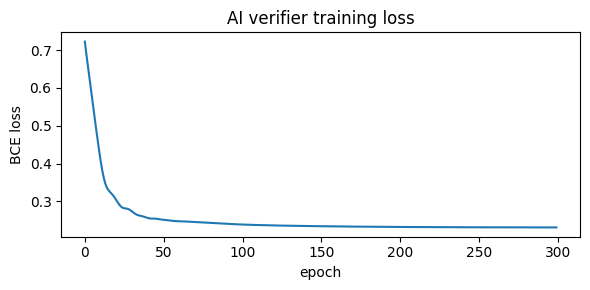

final training loss: 0.2315


In [14]:
# ---------------------------------------------------------------------------
# Small physics-informed confidence MLP
# ---------------------------------------------------------------------------
class ConfidenceVerifier(nn.Module):
    def __init__(self, n_features=7, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = ConfidenceVerifier().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.BCELoss()

Xt = torch.tensor(X_train_n, device=DEVICE)
yt = torch.tensor(y_train, device=DEVICE)

train_losses = []
for epoch in range(300):
    opt.zero_grad()
    pred = model(Xt)
    loss = loss_fn(pred, yt)
    loss.backward()
    opt.step()
    train_losses.append(loss.item())

plt.figure(figsize=(6, 3))
plt.plot(train_losses)
plt.title("AI verifier training loss")
plt.xlabel("epoch"); plt.ylabel("BCE loss")
plt.tight_layout()
plt.show()
print(f"final training loss: {train_losses[-1]:.4f}")


In [15]:
# ---------------------------------------------------------------------------
# Run the AI verifier on the real dataset's physics features
# ---------------------------------------------------------------------------
real_features = np.array([metrics[k] for k in FEATURE_NAMES], dtype=np.float32)
real_features_n = normalize_features(real_features[None, :])

model.eval()
with torch.no_grad():
    ai_confidence = float(model(torch.tensor(real_features_n, device=DEVICE)).cpu().item())

if ai_confidence >= 0.8:
    ai_verdict = "PASS"
elif ai_confidence >= 0.5:
    ai_verdict = "CHECK"
else:
    ai_verdict = "FAIL"

print("Physics-Informed AI Verifier")
print(f"  Confidence: {ai_confidence:.2f}")
print(f"  Verdict   : {ai_verdict}")


Physics-Informed AI Verifier
  Confidence: 0.00
  Verdict   : FAIL


## Part 5 — Optical Receiver Dashboard

A single figure summarizing the full receiver run: measured vs reconstructed intensity,
recovered phase, TDGSA convergence, the physics verification report, the AI confidence
verdict, runtime, and reproducibility information.


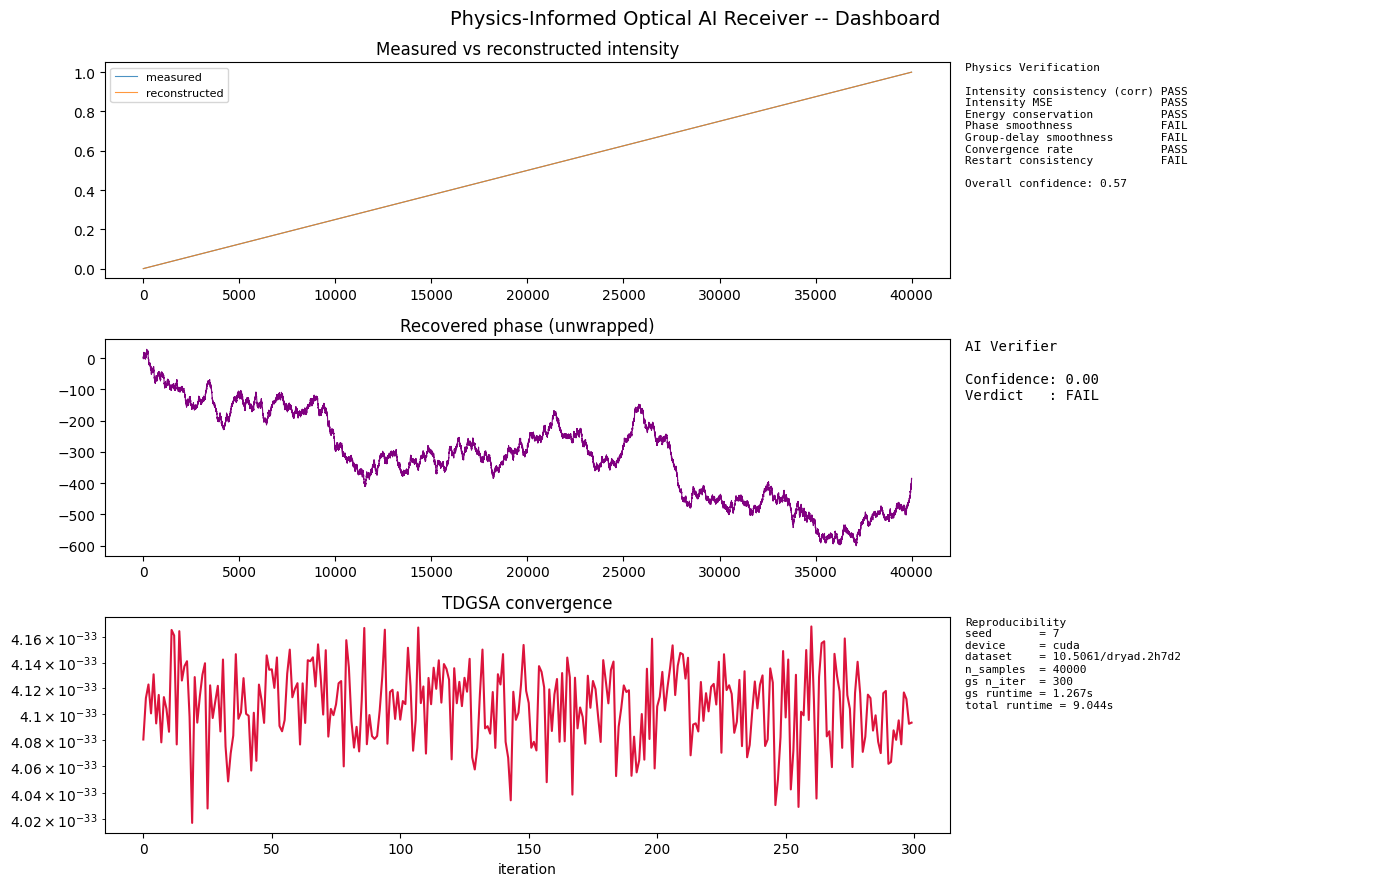


Total notebook runtime so far: 9.04s


In [16]:
# ---------------------------------------------------------------------------
# Final dashboard
# ---------------------------------------------------------------------------
runtime_total = time.time() - NOTEBOOK_T0

fig = plt.figure(figsize=(14, 9))
gs_grid = fig.add_gridspec(3, 3)

ax1 = fig.add_subplot(gs_grid[0, :2])
ax1.plot(I_meas, label="measured", lw=0.8, alpha=0.8)
ax1.plot(I_rec, label="reconstructed", lw=0.8, alpha=0.8)
ax1.set_title("Measured vs reconstructed intensity")
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs_grid[1, :2])
ax2.plot(phase_rec, color="purple", lw=0.8)
ax2.set_title("Recovered phase (unwrapped)")

ax3 = fig.add_subplot(gs_grid[2, :2])
ax3.semilogy(gs_errors, color="crimson")
ax3.set_title("TDGSA convergence")
ax3.set_xlabel("iteration")

ax4 = fig.add_subplot(gs_grid[0, 2])
ax4.axis("off")
report_lines = ["Physics Verification", ""]
for name, g in grades.items():
    report_lines.append(f"{name:28s} {g}")
report_lines.append("")
report_lines.append(f"Overall confidence: {overall_confidence:.2f}")
ax4.text(0, 1, "\n".join(report_lines), va="top", fontsize=8, family="monospace")

ax5 = fig.add_subplot(gs_grid[1, 2])
ax5.axis("off")
ax5.text(0, 1,
         f"AI Verifier\n\nConfidence: {ai_confidence:.2f}\nVerdict   : {ai_verdict}",
         va="top", fontsize=10, family="monospace")

ax6 = fig.add_subplot(gs_grid[2, 2])
ax6.axis("off")
repro_lines = [
    "Reproducibility",
    f"seed       = {SEED}",
    f"device     = {DEVICE}",
    f"dataset    = {DATASET_DOI}",
    f"n_samples  = {N}",
    f"gs n_iter  = 300",
    f"gs runtime = {gs_runtime:.3f}s",
    f"total runtime = {runtime_total:.3f}s",
]
ax6.text(0, 1, "\n".join(repro_lines), va="top", fontsize=8, family="monospace")

fig.suptitle("Physics-Informed Optical AI Receiver -- Dashboard", fontsize=14)
fig.tight_layout()
plt.show()

print(f"\nTotal notebook runtime so far: {runtime_total:.2f}s")


## Summary

This notebook implements a full computational-optics inverse-problem pipeline: a generic
multi-format dataset loader, a modular TDGSA phase-recovery algorithm, a physics-only
verification report (no hidden ground truth required), and a physics-informed AI confidence
estimator trained purely on the *shape* of good vs. degraded reconstructions. The same
modules (`tdgsa`, `intensity_mse`, `restart_consistency`, `ConfidenceVerifier`, ...) generalize
directly to other intensity-only phase-retrieval problems in computational photonics —
swap the loader's target directory and re-run.
